In [1]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

2025-02-12 18:03:10.793619: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-12 18:03:10.799602: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-12 18:03:10.819895: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-12 18:03:10.854432: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-12 18:03:10.864557: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-12 18:03:10.889960: I tensorflow/core/platform/cpu_feature_gu

In [2]:
dataset = 'dataset_angle_new.csv'
model_save_path = 'pose_detector_angle_3.keras'
model_save_name = 'pose_detector_angle_3'
model_tflite_name = 'pose_detector_angle_3.tflite'

In [3]:
NUM_CLASSES = 9

In [4]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(2, 5 + 1)))

In [5]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(1))

In [6]:
# y_dataset = y_dataset - 1
X_dataset.shape

(2951, 4)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# Model building

In [8]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((4, )),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [9]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20)             │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 529 (2.07 KB)

 Trainable params: 469 (1.83 KB)

 Non-trainable params: 60 (240.00 B)

In [10]:
# Model checkpoint callback
# path_model = os.path.dirname(model_save_path)
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=model_save_path, verbose=1, save_weights_only=False
)
# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [11]:
# Model compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model training

In [12]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
15/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1179 - loss: 2.4249
Epoch 1: saving model to pose_detector_angle_3.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.1178 - loss: 2.4140 - val_accuracy: 0.0081 - val_loss: 6.6990
Epoch 2/1000
 1/18 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1328 - loss: 2.2330
Epoch 2: saving model to pose_detector_angle_3.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1774 - loss: 2.1681 - val_accuracy: 0.1965 - val_loss: 4.4533
Epoch 3/1000
 1/18 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2578 - loss: 1.9357
Epoch 3: saving model to pose_detector_angle_3.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2751 - loss: 1.9096 - val_accuracy: 0.2222 - val_loss: 3.3253
Epoch 4/1000
 1/18 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3594 - loss: 1.7597
Epoch 4: saving model to pose_detector_angle_3.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3735 - loss: 1.7362 - val_accuracy: 0.3306

In [13]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9951 - loss: 0.0309 


In [14]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [15]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
[1.2752649e-08 5.5817919e-09 9.9716741e-01 1.0852682e-03 4.4395009e-04
 6.6538295e-04 1.7584680e-08 6.5266264e-08 6.3790742e-04]
2


In [16]:
y_test[0]

2

# Save Model to TFfile

In [17]:
model.export(model_save_name)

INFO:tensorflow:Assets written to: pose_detector_angle_3/assets


INFO:tensorflow:Assets written to: pose_detector_angle_3/assets


Saved artifact at 'pose_detector_angle_3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  140560594021264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140560724699696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140561672695200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140560759527328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140560594673808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140560594677856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140560594165024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140560594159568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140560326981440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140560326976160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140560326975280: Ten

In [18]:
converter = tf.lite.TFLiteConverter.from_saved_model(model_save_name)
tflite_model = converter.convert()

W0000 00:00:1739354637.649811   26483 tf_tfl_flatbuffer_helpers.cc:392] Ignored output_format.
W0000 00:00:1739354637.649842   26483 tf_tfl_flatbuffer_helpers.cc:395] Ignored drop_control_dependency.
2025-02-12 18:03:57.650195: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: pose_detector_angle_3
2025-02-12 18:03:57.651169: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-02-12 18:03:57.651206: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: pose_detector_angle_3
2025-02-12 18:03:57.659216: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2025-02-12 18:03:57.660540: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-02-12 18:03:57.700709: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: pose_detector_angle_3
2025-02-12 18:03:57.711466: I tensorflow/cc/saved_

In [19]:
with open(model_tflite_name, 'wb') as f:
    f.write(tflite_model)

# Confussion Matrix

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


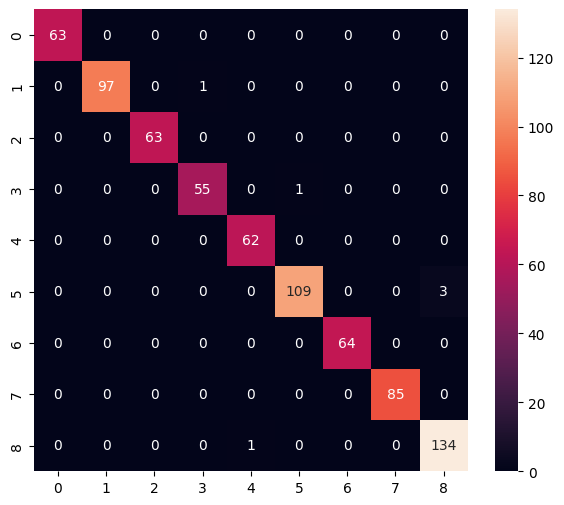

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        63
           1       1.00      0.99      0.99        98
           2       1.00      1.00      1.00        63
           3       0.98      0.98      0.98        56
           4       0.98      1.00      0.99        62
           5       0.99      0.97      0.98       112
           6       1.00      1.00      1.00        64
           7       1.00      1.00      1.00        85
           8       0.98      0.99      0.99       135

    accuracy                           0.99       738
   macro avg       0.99      0.99      0.99       738
weighted avg       0.99      0.99      0.99       738



In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)

    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()

    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

In [21]:
labels = sorted(list(set(y_test)))
confusion_matrix(y_test, y_pred, labels=labels)

array([[ 63,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,  97,   0,   1,   0,   0,   0,   0,   0],
       [  0,   0,  63,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,  55,   0,   1,   0,   0,   0],
       [  0,   0,   0,   0,  62,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0, 109,   0,   0,   3],
       [  0,   0,   0,   0,   0,   0,  64,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  85,   0],
       [  0,   0,   0,   0,   1,   0,   0,   0, 134]])